In [110]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [111]:
import os

MRI_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri"

print(os.listdir(MRI_PATH))

['ACDC_preprocessed', 'ACDC', 'acdc_patient_labels.csv', 'acdc_val_patients.csv', 'acdc_test_patients.csv', 'acdc_train_patients.csv']


In [112]:
import os

MRI_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri"

print("MRI folder:")
print(os.listdir(MRI_PATH))

ACDC_PATH = os.path.join(MRI_PATH, "ACDC_preprocessed")

print("\nACDC folder:")
print(os.listdir(ACDC_PATH))

MRI folder:
['ACDC_preprocessed', 'ACDC', 'acdc_patient_labels.csv', 'acdc_val_patients.csv', 'acdc_test_patients.csv', 'acdc_train_patients.csv']

ACDC folder:
['ACDC_testing_volumes', 'ACDC_training_volumes', 'ACDC_training_slices']


In [113]:
import os

SLICES_PATH = os.path.join(
    ACDC_PATH,
    "ACDC_training_slices"
)

files = os.listdir(SLICES_PATH)

print("Number of files:", len(files))
print("\nFirst 10 files:")
print(files[:10])

Number of files: 1937

First 10 files:
['patient051_frame01_slice_7.h5', 'patient052_frame01_slice_4.h5', 'patient051_frame11_slice_1.h5', 'patient053_frame12_slice_3.h5', 'patient049_frame01_slice_3.h5', 'patient056_frame01_slice_6.h5', 'patient050_frame01_slice_6.h5', 'patient055_frame10_slice_2.h5', 'patient055_frame01_slice_8.h5', 'patient052_frame09_slice_6.h5']


In [114]:
print("First 20 files:")
for f in files[:20]:
    print(f)

First 20 files:
patient051_frame01_slice_7.h5
patient052_frame01_slice_4.h5
patient051_frame11_slice_1.h5
patient053_frame12_slice_3.h5
patient049_frame01_slice_3.h5
patient056_frame01_slice_6.h5
patient050_frame01_slice_6.h5
patient055_frame10_slice_2.h5
patient055_frame01_slice_8.h5
patient052_frame09_slice_6.h5
patient048_frame01_slice_4.h5
patient054_frame12_slice_1.h5
patient053_frame01_slice_6.h5
patient048_frame08_slice_7.h5
patient056_frame12_slice_2.h5
patient051_frame01_slice_5.h5
patient055_frame10_slice_5.h5
patient051_frame01_slice_1.h5
patient054_frame01_slice_4.h5
patient051_frame11_slice_5.h5


In [115]:
import h5py
import os

sample_file = os.path.join(
    SLICES_PATH,
    "patient001_frame01_slice_1.h5"
)

with h5py.File(sample_file, "r") as f:
    print("Keys inside the file:")
    print(list(f.keys()))

    for key in f.keys():
        print(key, "shape =", f[key].shape, "dtype =", f[key].dtype)

Keys inside the file:
['image', 'label', 'scribble']
image shape = (256, 216) dtype = float32
label shape = (256, 216) dtype = uint8
scribble shape = (256, 216) dtype = uint16


Image range: 0.0 to 1.0
Label values: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]


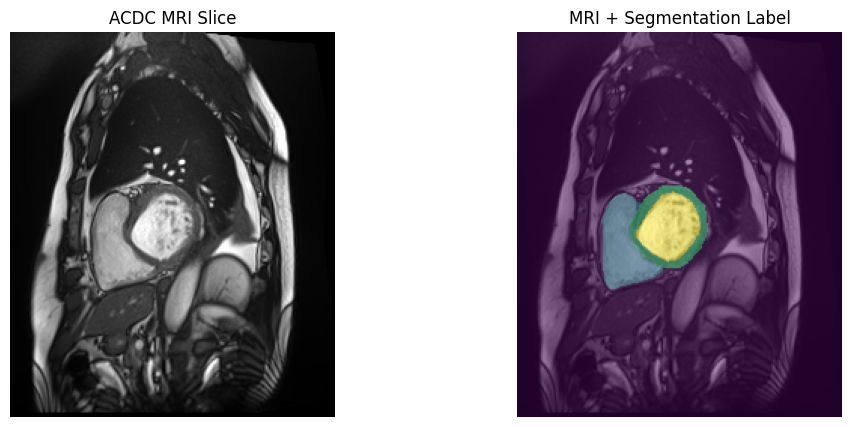

In [116]:
import h5py
import matplotlib.pyplot as plt

with h5py.File(sample_file, "r") as f:
    image = f["image"][:]
    label = f["label"][:]

print("Image range:", image.min(), "to", image.max())
print("Label values:", sorted(set(label.flatten())))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("ACDC MRI Slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image, cmap="gray")
plt.imshow(label, alpha=0.5)
plt.title("MRI + Segmentation Label")
plt.axis("off")

plt.show()

In [117]:
import numpy as np

for value in [0, 1, 2, 3]:
    count = np.sum(label == value)
    print(f"Label {value}: {count} pixels")

Label 0: 51669 pixels
Label 1: 1455 pixels
Label 2: 821 pixels
Label 3: 1351 pixels


In [118]:
import numpy as np

for value in [0, 1, 2, 3]:
    count = np.sum(label == value)
    print(f"Label {value}: {count} pixels")

Label 0: 51669 pixels
Label 1: 1455 pixels
Label 2: 821 pixels
Label 3: 1351 pixels


In [119]:
VOLUMES_PATH = os.path.join(
    ACDC_PATH,
    "ACDC_training_volumes"
)

volume_files = os.listdir(VOLUMES_PATH)

print("Number of volume files:", len(volume_files))
print("\nFirst 20 files:")
for f in volume_files[:20]:
    print(f)

Number of volume files: 200

First 20 files:
patient002_frame12.h5
patient007_frame07.h5
patient007_frame01.h5
patient001_frame01.h5
patient005_frame13.h5
patient001_frame12.h5
patient006_frame01.h5
patient003_frame01.h5
patient005_frame01.h5
patient008_frame13.h5
patient004_frame15.h5
patient002_frame01.h5
patient008_frame01.h5
patient006_frame16.h5
patient003_frame15.h5
patient004_frame01.h5
patient046_frame10.h5
patient013_frame14.h5
patient016_frame12.h5
patient019_frame11.h5


In [120]:
sample_volume = os.path.join(
    VOLUMES_PATH,
    "patient001_frame01.h5"
)

with h5py.File(sample_volume, "r") as f:
    print("Keys inside volume file:")
    print(list(f.keys()))

    for key in f.keys():
        print(
            key,
            "shape =", f[key].shape,
            "dtype =", f[key].dtype
        )

Keys inside volume file:
['image', 'label', 'scribble']
image shape = (10, 256, 216) dtype = float32
label shape = (10, 256, 216) dtype = uint8
scribble shape = (10, 256, 216) dtype = uint16


Volume shape: (10, 256, 216)
Mask shape: (10, 256, 216)
Mask values: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]


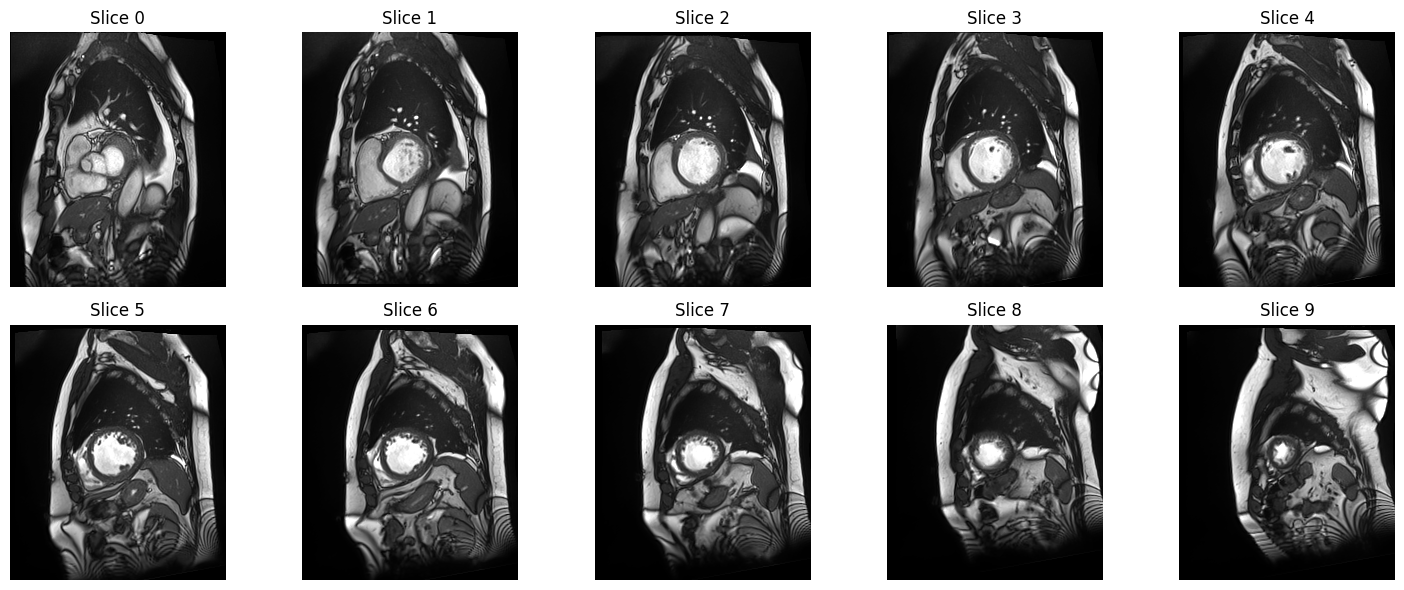

In [121]:
import matplotlib.pyplot as plt
import h5py

with h5py.File(sample_volume, "r") as f:
    volume = f["image"][:]
    masks = f["label"][:]

print("Volume shape:", volume.shape)
print("Mask shape:", masks.shape)
print("Mask values:", sorted(set(masks.flatten())))

# Show all 10 MRI slices
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(volume[i], cmap="gray")
    ax.set_title(f"Slice {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

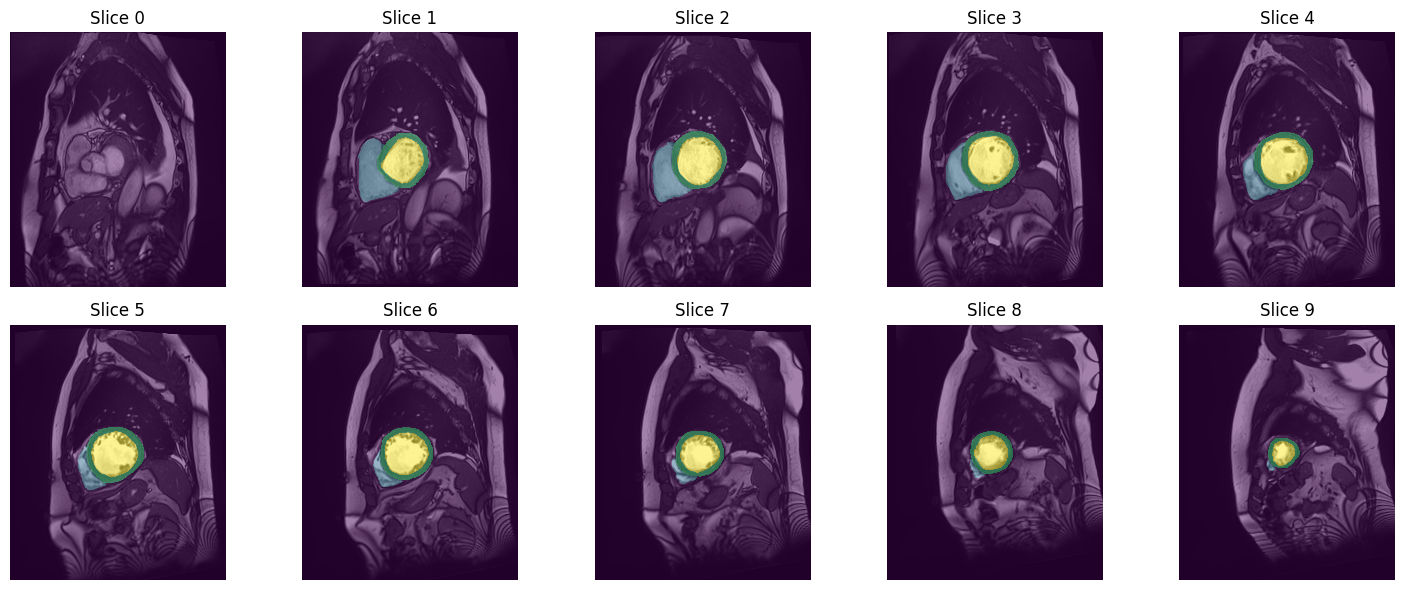

In [122]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(volume[i], cmap="gray")
    ax.imshow(masks[i], alpha=0.5)
    ax.set_title(f"Slice {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [123]:
import os

print("Searching for metadata files...")

for root, dirs, filenames in os.walk(ACDC_PATH):
    for f in filenames:
        if f.lower() in ["info.cfg", "info.txt", "dataset.json"]:
            print(os.path.join(root, f))

Searching for metadata files...


In [124]:
import os

for root, dirs, filenames in os.walk(ACDC_PATH):
    level = root.replace(ACDC_PATH, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for f in filenames[:5]:
        print(f"{indent}  {f}")

    if level >= 2:
        dirs[:] = []

ACDC_preprocessed/
  ACDC_testing_volumes/
    patient101_frame01.h5
    patient126_frame07.h5
    patient120_frame01.h5
    patient123_frame11.h5
    patient128_frame01.h5
  ACDC_training_volumes/
    patient002_frame12.h5
    patient007_frame07.h5
    patient007_frame01.h5
    patient001_frame01.h5
    patient005_frame13.h5
  ACDC_training_slices/
    patient051_frame01_slice_7.h5
    patient052_frame01_slice_4.h5
    patient051_frame11_slice_1.h5
    patient053_frame12_slice_3.h5
    patient049_frame01_slice_3.h5


In [125]:
import re

patient_ids = set()
frame_counts = {}

for f in volume_files:
    match = re.match(r"(patient\d+)_frame(\d+)\.h5$", f)

    if match:
        patient = match.group(1)
        frame = match.group(2)

        patient_ids.add(patient)

        if patient not in frame_counts:
            frame_counts[patient] = []
        frame_counts[patient].append(frame)

print("Unique patients:", len(patient_ids))
print("Total volume files:", len(volume_files))

print("\nFirst 10 patients and their frames:")
for patient in sorted(patient_ids)[:10]:
    print(patient, sorted(frame_counts[patient]))

Unique patients: 100
Total volume files: 200

First 10 patients and their frames:
patient001 ['01', '12']
patient002 ['01', '12']
patient003 ['01', '15']
patient004 ['01', '15']
patient005 ['01', '13']
patient006 ['01', '16']
patient007 ['01', '07']
patient008 ['01', '13']
patient009 ['01', '13']
patient010 ['01', '13']


In [126]:
with h5py.File(sample_volume, "r") as f:
    print("File attributes:")
    for key, value in f.attrs.items():
        print(key, "=", value)

File attributes:


In [127]:

import os

BASE_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri"

print("Files/folders directly inside MRI folder:")
for item in os.listdir(BASE_PATH):
    print(item)

Files/folders directly inside MRI folder:
ACDC_preprocessed
ACDC
acdc_patient_labels.csv
acdc_val_patients.csv
acdc_test_patients.csv
acdc_train_patients.csv


In [128]:
import os

ACDC_NEW_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC"

print("ACDC path exists:", os.path.exists(ACDC_NEW_PATH))
print("\nContents of ACDC:")

for item in os.listdir(ACDC_NEW_PATH):
    full_path = os.path.join(ACDC_NEW_PATH, item)

    if os.path.isdir(full_path):
        print("[FOLDER] ", item)
    else:
        print("[FILE]   ", item)

ACDC path exists: True

Contents of ACDC:
[FOLDER]  database


In [129]:
import os

TRAINING_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training"

print("Training path exists:", os.path.exists(TRAINING_PATH))

patients = [
    f for f in os.listdir(TRAINING_PATH)
    if os.path.isdir(os.path.join(TRAINING_PATH, f))
]

print("Number of patient folders:", len(patients))
print("First 10:", sorted(patients)[:10])
print("Last 10:", sorted(patients)[-10:])

Training path exists: True
Number of patient folders: 100
First 10: ['patient001', 'patient002', 'patient003', 'patient004', 'patient005', 'patient006', 'patient007', 'patient008', 'patient009', 'patient010']
Last 10: ['patient091', 'patient092', 'patient093', 'patient094', 'patient095', 'patient096', 'patient097', 'patient098', 'patient099', 'patient100']


In [130]:
import os

PATIENT_PATH = os.path.join(TRAINING_PATH, "patient001")

print("Files in patient001:")
for f in sorted(os.listdir(PATIENT_PATH)):
    print(f)

Files in patient001:
Info.cfg
MANDATORY_CITATION.md
patient001_4d.nii.gz
patient001_frame01.nii.gz
patient001_frame01_gt.nii.gz
patient001_frame12.nii.gz
patient001_frame12_gt.nii.gz


In [131]:
INFO_PATH = os.path.join(PATIENT_PATH, "Info.cfg")

with open(INFO_PATH, "r") as f:
    info = f.read()

print(info)

ED: 1
ES: 12
Group: DCM
Height: 184.0
NbFrame: 30
Weight: 95.0



In [132]:
import os
import re
import pandas as pd

records = []

for patient in sorted(os.listdir(TRAINING_PATH)):
    patient_path = os.path.join(TRAINING_PATH, patient)

    if not os.path.isdir(patient_path):
        continue

    info_path = os.path.join(patient_path, "Info.cfg")

    if not os.path.exists(info_path):
        continue

    with open(info_path, "r") as f:
        text = f.read()

    group_match = re.search(r"Group:\s*(\S+)", text)
    ed_match = re.search(r"ED:\s*(\d+)", text)
    es_match = re.search(r"ES:\s*(\d+)", text)

    records.append({
        "patient_id": patient,
        "diagnosis": group_match.group(1) if group_match else None,
        "ED": int(ed_match.group(1)) if ed_match else None,
        "ES": int(es_match.group(1)) if es_match else None
    })

df = pd.DataFrame(records)

print("Number of patients:", len(df))
print("\nDiagnosis distribution:")
print(df["diagnosis"].value_counts())

print("\nFirst 10 patients:")
display(df.head(10))

Number of patients: 100

Diagnosis distribution:
diagnosis
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64

First 10 patients:


,patient_id,diagnosis,ED,ES
0,patient001,DCM,1,12
1,patient002,DCM,1,12
2,patient003,DCM,1,15
3,patient004,DCM,1,15
4,patient005,DCM,1,13
5,patient006,DCM,1,16
6,patient007,DCM,1,7
7,patient008,DCM,1,13
8,patient009,DCM,1,13
9,patient010,DCM,1,13


In [133]:
LABEL_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_patient_labels.csv"

df.to_csv(LABEL_PATH, index=False)

print("Saved successfully!")
print(LABEL_PATH)

Saved successfully!
/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_patient_labels.csv


In [134]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["diagnosis"],
    random_state=42
)

# Second split: 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["diagnosis"],
    random_state=42
)

print("Train patients:", len(train_df))
print("Validation patients:", len(val_df))
print("Test patients:", len(test_df))

print("\nTrain distribution:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["diagnosis"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["diagnosis"].value_counts().sort_index())

Train patients: 70
Validation patients: 15
Test patients: 15

Train distribution:
diagnosis
DCM     14
HCM     14
MINF    14
NOR     14
RV      14
Name: count, dtype: int64

Validation distribution:
diagnosis
DCM     3
HCM     3
MINF    3
NOR     3
RV      3
Name: count, dtype: int64

Test distribution:
diagnosis
DCM     3
HCM     3
MINF    3
NOR     3
RV      3
Name: count, dtype: int64


In [135]:

TRAIN_SPLIT_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_train_patients.csv"
VAL_SPLIT_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_val_patients.csv"
TEST_SPLIT_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_test_patients.csv"

train_df.to_csv(TRAIN_SPLIT_PATH, index=False)
val_df.to_csv(VAL_SPLIT_PATH, index=False)
test_df.to_csv(TEST_SPLIT_PATH, index=False)

print("Train split saved:", TRAIN_SPLIT_PATH)
print("Validation split saved:", VAL_SPLIT_PATH)
print("Test split saved:", TEST_SPLIT_PATH)

Train split saved: /content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_train_patients.csv
Validation split saved: /content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_val_patients.csv
Test split saved: /content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_test_patients.csv


In [136]:
import nibabel as nib
import os

PATIENT_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training/patient001"

for filename in [
    "patient001_4d.nii.gz",
    "patient001_frame01.nii.gz",
    "patient001_frame01_gt.nii.gz",
    "patient001_frame12.nii.gz",
    "patient001_frame12_gt.nii.gz"
]:
    filepath = os.path.join(PATIENT_PATH, filename)
    img = nib.load(filepath)

    print(f"{filename}")
    print("  Shape:", img.shape)
    print("  Data type:", img.get_fdata().dtype)
    print("  Voxel spacing:", img.header.get_zooms())
    print()

patient001_4d.nii.gz
  Shape: (216, 256, 10, 30)
  Data type: float64
  Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0), np.float32(1.0))

patient001_frame01.nii.gz
  Shape: (216, 256, 10)
  Data type: float64
  Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))

patient001_frame01_gt.nii.gz
  Shape: (216, 256, 10)
  Data type: float64
  Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))

patient001_frame12.nii.gz
  Shape: (216, 256, 10)
  Data type: float64
  Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))

patient001_frame12_gt.nii.gz
  Shape: (216, 256, 10)
  Data type: float64
  Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))



MRI shape: (216, 256, 10)
GT shape: (216, 256, 10)
GT labels: [0. 1. 2. 3.]


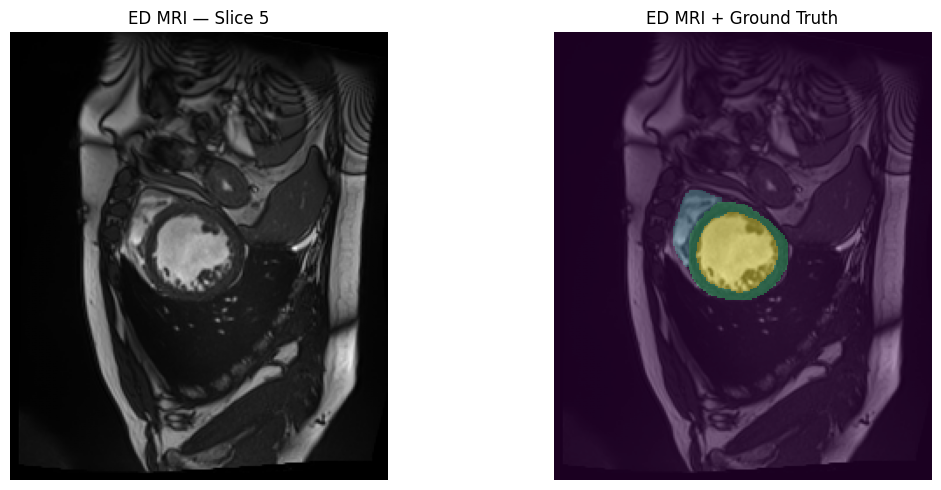

In [137]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

PATIENT_PATH = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training/patient001"

# Load ED MRI and ED ground-truth
mri_path = os.path.join(PATIENT_PATH, "patient001_frame01.nii.gz")
gt_path = os.path.join(PATIENT_PATH, "patient001_frame01_gt.nii.gz")

mri = nib.load(mri_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

print("MRI shape:", mri.shape)
print("GT shape:", gt.shape)
print("GT labels:", np.unique(gt))

# Select middle short-axis slice
slice_idx = mri.shape[2] // 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mri[:, :, slice_idx].T, cmap="gray", origin="lower")
plt.title(f"ED MRI — Slice {slice_idx}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mri[:, :, slice_idx].T, cmap="gray", origin="lower")
plt.imshow(
    gt[:, :, slice_idx].T,
    alpha=0.4,
    origin="lower",
    interpolation="nearest"
)
plt.title("ED MRI + Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

MRI shape: (216, 256, 10)
GT shape: (216, 256, 10)
Selected slice: 5
Labels: [0. 1. 2. 3.]


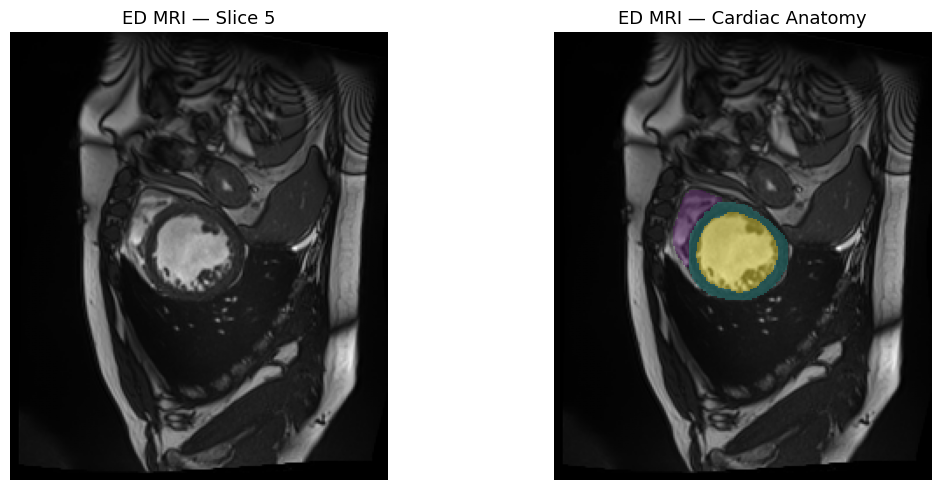


ACDC Cardiac Structures:
Label 1 → Right Ventricle (RV) cavity → Cyan/Teal
Label 2 → Myocardium → Green
Label 3 → Left Ventricle (LV) cavity → Yellow


In [138]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# Patient path
# ============================================================

PATIENT_PATH = (
    "/content/drive/MyDrive/Cardian_Nexus/data/mri/"
    "ACDC/database/training/patient001"
)

# ============================================================
# Load ED MRI and segmentation
# ============================================================

mri = nib.load(
    os.path.join(PATIENT_PATH, "patient001_frame01.nii.gz")
).get_fdata()

gt = nib.load(
    os.path.join(PATIENT_PATH, "patient001_frame01_gt.nii.gz")
).get_fdata()

# ============================================================
# Select middle slice
# ============================================================

slice_idx = mri.shape[2] // 2

image = mri[:, :, slice_idx].T
mask = gt[:, :, slice_idx].T

print("MRI shape:", mri.shape)
print("GT shape:", gt.shape)
print("Selected slice:", slice_idx)
print("Labels:", np.unique(mask))

# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(12, 5))

# ------------------------------------------------------------
# Left: Original ED MRI
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.imshow(
    image,
    cmap="gray",
    origin="lower"
)

plt.title(
    f"ED MRI — Slice {slice_idx}",
    fontsize=13
)

plt.axis("off")


# ------------------------------------------------------------
# Right: MRI + segmentation
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.imshow(
    image,
    cmap="gray",
    origin="lower"
)

# Use viridis to produce:
# Label 1 → cyan/teal
# Label 2 → green
# Label 3 → yellow

plt.imshow(
    np.ma.masked_where(mask == 0, mask),
    cmap="viridis",
    vmin=1,
    vmax=3,
    alpha=0.40,
    origin="lower",
    interpolation="nearest"
)

plt.title(
    "ED MRI — Cardiac Anatomy",
    fontsize=13
)

plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# ACDC anatomical labels
# ============================================================

print("\nACDC Cardiac Structures:")
print("Label 1 → Right Ventricle (RV) cavity → Cyan/Teal")
print("Label 2 → Myocardium → Green")
print("Label 3 → Left Ventricle (LV) cavity → Yellow")

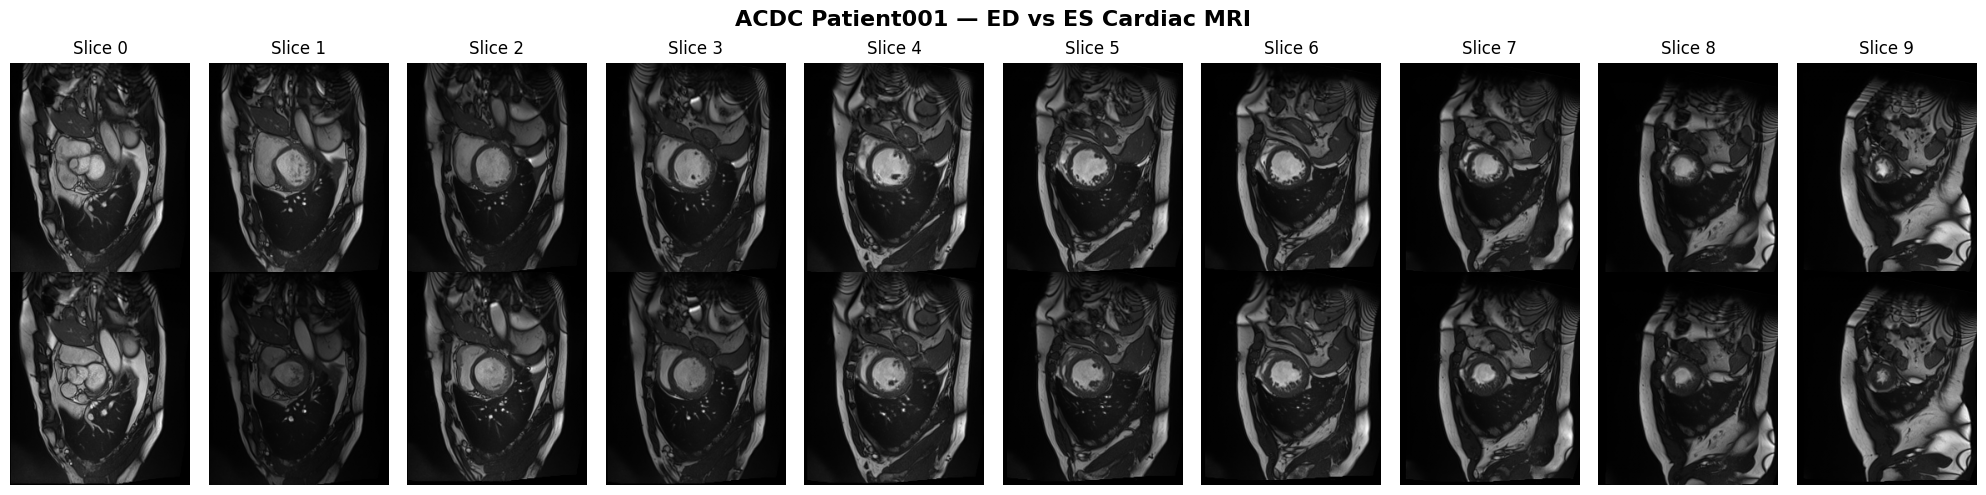

ED shape: (216, 256, 10)
ES shape: (216, 256, 10)
Number of slices: 10


In [139]:
import nibabel as nib
import matplotlib.pyplot as plt
import os

# ============================================================
# Patient
# ============================================================

PATIENT_PATH = (
    "/content/drive/MyDrive/Cardian_Nexus/data/mri/"
    "ACDC/database/training/patient001"
)

# ============================================================
# Load ED and ES MRI
# ============================================================

ed = nib.load(
    os.path.join(PATIENT_PATH, "patient001_frame01.nii.gz")
).get_fdata()

es = nib.load(
    os.path.join(PATIENT_PATH, "patient001_frame12.nii.gz")
).get_fdata()

# ============================================================
# Display all 10 slices
# ============================================================

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for slice_idx in range(ed.shape[2]):

    # -------------------------
    # ED
    # -------------------------
    axes[0, slice_idx].imshow(
        ed[:, :, slice_idx].T,
        cmap="gray",
        origin="lower"
    )

    axes[0, slice_idx].set_title(f"Slice {slice_idx}")
    axes[0, slice_idx].axis("off")

    # -------------------------
    # ES
    # -------------------------
    axes[1, slice_idx].imshow(
        es[:, :, slice_idx].T,
        cmap="gray",
        origin="lower"
    )

    axes[1, slice_idx].axis("off")


axes[0, 0].set_ylabel("ED", fontsize=14, fontweight="bold")
axes[1, 0].set_ylabel("ES", fontsize=14, fontweight="bold")

fig.suptitle(
    "ACDC Patient001 — ED vs ES Cardiac MRI",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("ED shape:", ed.shape)
print("ES shape:", es.shape)
print("Number of slices:", ed.shape[2])

In [140]:
import nibabel as nib
import numpy as np
import os

PATIENT_PATH = (
    "/content/drive/MyDrive/Cardian_Nexus/data/mri/"
    "ACDC/database/training/patient001"
)

# Load ED and ES ground-truth masks
ed_gt = nib.load(
    os.path.join(
        PATIENT_PATH,
        "patient001_frame01_gt.nii.gz"
    )
).get_fdata()

es_gt = nib.load(
    os.path.join(
        PATIENT_PATH,
        "patient001_frame12_gt.nii.gz"
    )
).get_fdata()

print("Patient001 cardiac structure coverage")
print("=" * 50)

for slice_idx in range(ed_gt.shape[2]):

    # Number of cardiac pixels in ED
    ed_pixels = np.sum(ed_gt[:, :, slice_idx] > 0)

    # Number of cardiac pixels in ES
    es_pixels = np.sum(es_gt[:, :, slice_idx] > 0)

    print(
        f"Slice {slice_idx}: "
        f"ED = {ed_pixels:6d} pixels | "
        f"ES = {es_pixels:6d} pixels"
    )

Patient001 cardiac structure coverage
Slice 0: ED =      0 pixels | ES =      0 pixels
Slice 1: ED =   3627 pixels | ES =   1636 pixels
Slice 2: ED =   3790 pixels | ES =   2981 pixels
Slice 3: ED =   3689 pixels | ES =   3128 pixels
Slice 4: ED =   3389 pixels | ES =   2902 pixels
Slice 5: ED =   3022 pixels | ES =   2657 pixels
Slice 6: ED =   2620 pixels | ES =   2296 pixels
Slice 7: ED =   2026 pixels | ES =   1806 pixels
Slice 8: ED =   1576 pixels | ES =   1408 pixels
Slice 9: ED =    816 pixels | ES =    856 pixels


In [141]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

TRAINING_PATH = (
    "/content/drive/MyDrive/Cardian_Nexus/data/mri/"
    "ACDC/database/training"
)

records = []

for patient in sorted(os.listdir(TRAINING_PATH)):

    patient_path = os.path.join(TRAINING_PATH, patient)

    if not os.path.isdir(patient_path):
        continue

    # Read ED and ES frame numbers from Info.cfg
    info_path = os.path.join(patient_path, "Info.cfg")

    with open(info_path, "r") as f:
        info = f.read()

    ed_frame = int(
        [line for line in info.splitlines()
         if line.startswith("ED:")][0].split(":")[1].strip()
    )

    es_frame = int(
        [line for line in info.splitlines()
         if line.startswith("ES:")][0].split(":")[1].strip()
    )

    # Ground-truth filenames
    ed_gt_path = os.path.join(
        patient_path,
        f"{patient}_frame{ed_frame:02d}_gt.nii.gz"
    )

    es_gt_path = os.path.join(
        patient_path,
        f"{patient}_frame{es_frame:02d}_gt.nii.gz"
    )

    ed_gt = nib.load(ed_gt_path).get_fdata()
    es_gt = nib.load(es_gt_path).get_fdata()

    # Count slices containing cardiac structures
    ed_valid = np.sum(
        np.sum(ed_gt > 0, axis=(0, 1)) > 0
    )

    es_valid = np.sum(
        np.sum(es_gt > 0, axis=(0, 1)) > 0
    )

    records.append({
        "patient_id": patient,
        "ED_frame": ed_frame,
        "ES_frame": es_frame,
        "ED_valid_slices": ed_valid,
        "ES_valid_slices": es_valid
    })

slice_stats = pd.DataFrame(records)

print("Patients analyzed:", len(slice_stats))
print()
print(slice_stats.head())

print("\nAverage valid slices:")
print("ED:", round(slice_stats["ED_valid_slices"].mean(), 2))
print("ES:", round(slice_stats["ES_valid_slices"].mean(), 2))

print("\nMinimum / Maximum:")
print(
    "ED:",
    slice_stats["ED_valid_slices"].min(),
    "-",
    slice_stats["ED_valid_slices"].max()
)

print(
    "ES:",
    slice_stats["ES_valid_slices"].min(),
    "-",
    slice_stats["ES_valid_slices"].max()
)

Patients analyzed: 100

   patient_id  ED_frame  ES_frame  ED_valid_slices  ES_valid_slices
0  patient001         1        12                9                9
1  patient002         1        12               10               10
2  patient003         1        15               10               10
3  patient004         1        15               10               10
4  patient005         1        13               10               10

Average valid slices:
ED: 9.4
ES: 9.01

Minimum / Maximum:
ED: 6 - 18
ES: 6 - 17


In [142]:
import nibabel as nib
import numpy as np
import os

PATIENT_PATH = (
    "/content/drive/MyDrive/Cardian_Nexus/data/mri/"
    "ACDC/database/training/patient001"
)

# Load ED and ES
ed = nib.load(
    os.path.join(
        PATIENT_PATH,
        "patient001_frame01.nii.gz"
    )
).get_fdata()

es = nib.load(
    os.path.join(
        PATIENT_PATH,
        "patient001_frame12.nii.gz"
    )
).get_fdata()

print("ED intensity statistics")
print("=" * 40)
print("Minimum :", np.min(ed))
print("Maximum :", np.max(ed))
print("Mean    :", np.mean(ed))
print("Std     :", np.std(ed))

print("\nES intensity statistics")
print("=" * 40)
print("Minimum :", np.min(es))
print("Maximum :", np.max(es))
print("Mean    :", np.mean(es))
print("Std     :", np.std(es))

ED intensity statistics
Minimum : 0.0
Maximum : 658.0
Mean    : 77.94703233506945
Std     : 88.6452010850085

ES intensity statistics
Minimum : 0.0
Maximum : 984.0
Mean    : 77.74873589409722
Std     : 87.52524617824635


ED normalization
1st percentile : 1.0
99th percentile: 345.0
New minimum    : 0.0
New maximum    : 1.0

ES normalization
1st percentile : 1.0
99th percentile: 340.0
New minimum    : 0.0
New maximum    : 1.0


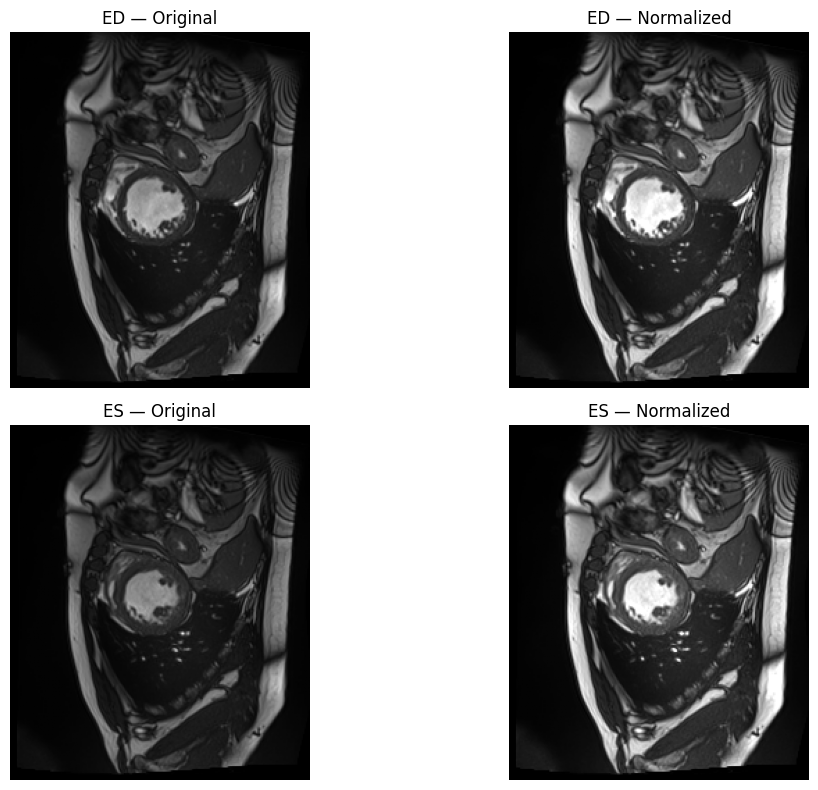

In [143]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Patient path
# ============================================================

PATIENT_PATH = (
    "/content/drive/MyDrive/Cardian_Nexus/data/mri/"
    "ACDC/database/training/patient001"
)

# ============================================================
# Load ED and ES
# ============================================================

ed = nib.load(
    os.path.join(
        PATIENT_PATH,
        "patient001_frame01.nii.gz"
    )
).get_fdata()

es = nib.load(
    os.path.join(
        PATIENT_PATH,
        "patient001_frame12.nii.gz"
    )
).get_fdata()


# ============================================================
# Robust normalization function
# ============================================================

def normalize_mri(image):

    # Work only with non-zero MRI pixels
    non_zero = image[image > 0]

    # Calculate robust intensity limits
    low = np.percentile(non_zero, 1)
    high = np.percentile(non_zero, 99)

    # Clip extreme intensities
    image = np.clip(image, low, high)

    # Normalize to [0, 1]
    image = (image - low) / (high - low)

    # Restore background as zero
    image[image < 0] = 0

    return image.astype(np.float32), low, high


# ============================================================
# Normalize ED and ES
# ============================================================

ed_norm, ed_low, ed_high = normalize_mri(ed)
es_norm, es_low, es_high = normalize_mri(es)

print("ED normalization")
print("1st percentile :", ed_low)
print("99th percentile:", ed_high)
print("New minimum    :", ed_norm.min())
print("New maximum    :", ed_norm.max())

print("\nES normalization")
print("1st percentile :", es_low)
print("99th percentile:", es_high)
print("New minimum    :", es_norm.min())
print("New maximum    :", es_norm.max())


# ============================================================
# Visual comparison
# ============================================================

slice_idx = 5

plt.figure(figsize=(12, 8))

# ED original
plt.subplot(2, 2, 1)
plt.imshow(
    ed[:, :, slice_idx].T,
    cmap="gray",
    origin="lower"
)
plt.title("ED — Original")
plt.axis("off")

# ED normalized
plt.subplot(2, 2, 2)
plt.imshow(
    ed_norm[:, :, slice_idx].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
plt.title("ED — Normalized")
plt.axis("off")

# ES original
plt.subplot(2, 2, 3)
plt.imshow(
    es[:, :, slice_idx].T,
    cmap="gray",
    origin="lower"
)
plt.title("ES — Original")
plt.axis("off")

# ES normalized
plt.subplot(2, 2, 4)
plt.imshow(
    es_norm[:, :, slice_idx].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
plt.title("ES — Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

In [144]:
import os

print(os.path.exists("/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_patient_labels.csv"))
print(os.path.exists("/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_train_patients.csv"))
print(os.path.exists("/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_val_patients.csv"))
print(os.path.exists("/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_test_patients.csv"))

True
True
True
True


In [145]:
import os

DATA_ROOT = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training"

print(os.path.exists(DATA_ROOT))

True


In [146]:
import os

patient_path = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training/patient001"

print(os.listdir(patient_path))

['patient001_frame12.nii.gz', 'patient001_frame12_gt.nii.gz', 'patient001_frame01.nii.gz', 'MANDATORY_CITATION.md', 'Info.cfg', 'patient001_4d.nii.gz', 'patient001_frame01_gt.nii.gz']


In [147]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_train_patients.csv"
)

print(df.columns)

Index(['patient_id', 'diagnosis', 'ED', 'ES'], dtype='object')


In [148]:
import pandas as pd

TRAIN_CSV = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_train_patients.csv"

df = pd.read_csv(TRAIN_CSV)

print(df.head())
print()
print(df.columns)

   patient_id diagnosis  ED  ES
0  patient078       NOR   1   9
1  patient087        RV   1  10
2  patient043      MINF   1   7
3  patient048      MINF   1   8
4  patient035       HCM   1  11

Index(['patient_id', 'diagnosis', 'ED', 'ES'], dtype='object')


In [149]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import torch
from torch.utils.data import Dataset

# --------------------------------------------------
# Paths
# --------------------------------------------------

DATA_ROOT = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training"

# --------------------------------------------------
# Label mapping
# --------------------------------------------------

label_map = {
    "NOR": 0,
    "DCM": 1,
    "HCM": 2,
    "MINF": 3,
    "RV": 4
}

# --------------------------------------------------
# Normalization
# --------------------------------------------------

def normalize_image(img):

    non_zero = img[img > 0]

    if len(non_zero) > 0:
        p1 = np.percentile(non_zero, 1)
        p99 = np.percentile(non_zero, 99)

        img = np.clip(img, p1, p99)
        img = (img - p1) / (p99 - p1 + 1e-8)

    return img.astype(np.float32)

# --------------------------------------------------
# Dataset
# --------------------------------------------------

class ACDCDataset(Dataset):

    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        patient_id = row["patient_id"]
        diagnosis = row["diagnosis"]
        ed_frame = int(row["ED"])

        patient_folder = os.path.join(
            DATA_ROOT,
            patient_id
        )

        filename = (
            f"{patient_id}_frame{ed_frame:02d}.nii.gz"
        )

        volume_path = os.path.join(
            patient_folder,
            filename
        )

        volume = nib.load(
            volume_path
        ).get_fdata()

        volume = normalize_image(volume)

        # (H,W,S) -> (S,H,W)
        volume = np.transpose(
            volume,
            (2, 0, 1)
        )

        volume = torch.tensor(
            volume,
            dtype=torch.float32
        )

        label = torch.tensor(
            label_map[diagnosis],
            dtype=torch.long
        )

        return volume, label

In [150]:
TRAIN_CSV = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_train_patients.csv"

dataset = ACDCDataset(TRAIN_CSV)

print("Dataset size:", len(dataset))

volume, label = dataset[0]

print("Volume shape:", volume.shape)
print("Label:", label)

Dataset size: 70
Volume shape: torch.Size([8, 216, 256])
Label: tensor(0)


In [151]:
slice_counts = []

for i in range(len(dataset)):
    volume, label = dataset[i]
    slice_counts.append(volume.shape[0])

print("Minimum slices:", min(slice_counts))
print("Maximum slices:", max(slice_counts))
print("Unique slice counts:", sorted(set(slice_counts)))

Minimum slices: 6
Maximum slices: 17
Unique slice counts: [6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


In [152]:
import torch
import numpy as np

def standardize_slices(volume, target_slices=8):
    # volume shape: [S, H, W]

    s, h, w = volume.shape

    if s > target_slices:
        start = (s - target_slices) // 2
        volume = volume[start:start + target_slices]

    elif s < target_slices:
        pad_before = (target_slices - s) // 2
        pad_after = target_slices - s - pad_before

        volume = np.pad(
            volume,
            ((pad_before, pad_after), (0, 0), (0, 0)),
            mode="constant"
        )

    return volume


# Test on first sample
volume, label = dataset[0]

volume_np = volume.numpy()

volume_std = standardize_slices(volume_np)

print("Original shape:", volume.shape)
print("Standardized shape:", volume_std.shape)

Original shape: torch.Size([8, 216, 256])
Standardized shape: (8, 216, 256)


In [153]:
for i in [0, 10, 20, 30, 40]:
    volume, label = dataset[i]

    volume_std = standardize_slices(
        volume.numpy(),
        target_slices=8
    )

    print(
        f"Patient {i}: "
        f"{volume.shape} -> {volume_std.shape}"
    )

Patient 0: torch.Size([8, 216, 256]) -> (8, 216, 256)
Patient 10: torch.Size([9, 240, 256]) -> (8, 240, 256)
Patient 20: torch.Size([9, 256, 256]) -> (8, 256, 256)
Patient 30: torch.Size([6, 216, 256]) -> (8, 216, 256)
Patient 40: torch.Size([8, 208, 256]) -> (8, 208, 256)


In [154]:
from skimage.transform import resize
import numpy as np

def resize_volume(volume, target_size=(224, 224)):
    """
    Input:
        volume -> (S, H, W)

    Output:
        (S, 224, 224)
    """

    resized = []

    for s in range(volume.shape[0]):

        img = resize(
            volume[s],
            target_size,
            preserve_range=True,
            anti_aliasing=True
        )

        resized.append(img)

    return np.array(resized, dtype=np.float32)


# Test on one sample
volume, label = dataset[20]

volume_std = standardize_slices(
    volume.numpy(),
    target_slices=8
)

volume_resized = resize_volume(
    volume_std,
    target_size=(224,224)
)

print("Before:", volume_std.shape)
print("After :", volume_resized.shape)

Before: (8, 256, 256)
After : (8, 224, 224)


In [155]:
import nibabel as nib
import numpy as np
import torch

volume_path = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training/patient001/patient001_frame01.nii.gz"

volume = nib.load(volume_path).get_fdata()

volume = normalize_image(volume)

volume = np.transpose(
    volume,
    (2, 0, 1)
)

volume = standardize_slices(
    volume,
    target_slices=8
)

volume = resize_volume(
    volume,
    target_size=(224, 224)
)

volume = torch.tensor(
    volume,
    dtype=torch.float32
)


In [156]:
import os
import pandas as pd
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset

class ACDCDataset(Dataset):

    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        patient_id = row["patient_id"]
        diagnosis = row["diagnosis"]
        ed_frame = int(row["ED"])

        return patient_id, diagnosis, ed_frame

In [157]:
dataset = ACDCDataset(TRAIN_CSV)

print("Dataset size:", len(dataset))

print(dataset[0])

Dataset size: 70
('patient078', 'NOR', 1)


In [158]:
print("normalize_image:", callable(normalize_image))
print("standardize_slices:", callable(standardize_slices))
print("resize_volume:", callable(resize_volume))

normalize_image: True
standardize_slices: True
resize_volume: True


In [159]:
import torchvision.transforms as T

augment = T.Compose([
    T.RandomRotation(15),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    )
])

In [160]:
import os
import pandas as pd
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset

DATA_ROOT = "/content/drive/MyDrive/Cardian_Nexus/data/mri/ACDC/database/training"

label_map = {
    "NOR": 0,
    "DCM": 1,
    "HCM": 2,
    "MINF": 3,
    "RV": 4
}


class ACDCDataset(Dataset):

    def __init__(self, csv_file, transform=None):

        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        patient_id = row["patient_id"]
        diagnosis = row["diagnosis"]

        ed_frame = int(row["ED"])
        es_frame = int(row["ES"])

        patient_folder = os.path.join(
            DATA_ROOT,
            patient_id
        )

        # --------------------
        # ED Volume
        # --------------------
        ed_path = os.path.join(
            patient_folder,
            f"{patient_id}_frame{ed_frame:02d}.nii.gz"
        )

        ed_volume = nib.load(
            ed_path
        ).get_fdata()

        ed_volume = normalize_image(
            ed_volume
        )

        ed_volume = np.transpose(
            ed_volume,
            (2, 0, 1)
        )

        ed_volume = standardize_slices(
            ed_volume,
            target_slices=8
        )

        ed_volume = resize_volume(
            ed_volume,
            target_size=(224, 224)
        )

        # --------------------
        # ES Volume
        # --------------------
        es_path = os.path.join(
            patient_folder,
            f"{patient_id}_frame{es_frame:02d}.nii.gz"
        )

        es_volume = nib.load(
            es_path
        ).get_fdata()

        es_volume = normalize_image(
            es_volume
        )

        es_volume = np.transpose(
            es_volume,
            (2, 0, 1)
        )

        es_volume = standardize_slices(
            es_volume,
            target_slices=8
        )

        es_volume = resize_volume(
            es_volume,
            target_size=(224, 224)
        )

        # --------------------
        # Combine ED + ES
        # --------------------
        volume = np.concatenate(
            [ed_volume, es_volume],
            axis=0
        )

        volume = torch.tensor(
            volume,
            dtype=torch.float32
        )

        # --------------------
        # Data Augmentation
        # --------------------
        if self.transform is not None:

            augmented = []

            for slice_img in volume:

                slice_img = self.transform(
                    slice_img.unsqueeze(0)
                )

                augmented.append(
                    slice_img.squeeze(0)
                )

            volume = torch.stack(
                augmented
            )

        label = torch.tensor(
            label_map[diagnosis],
            dtype=torch.long
        )

        return volume, label

In [161]:
import torchvision.transforms as T

augment = T.Compose([
    T.RandomRotation(15),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    )
])

In [162]:
TRAIN_CSV = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_train_patients.csv"

VAL_CSV = "/content/drive/MyDrive/Cardian_Nexus/data/mri/acdc_val_patients.csv"

In [163]:
train_dataset = ACDCDataset(
    TRAIN_CSV,
    transform=augment
)

val_dataset = ACDCDataset(
    VAL_CSV,
    transform=None
)

In [164]:
import os

print(os.path.exists(TRAIN_CSV))
print(os.path.exists(VAL_CSV))

True
True


In [165]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

In [166]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([4, 16, 224, 224])
torch.Size([4])


In [167]:
sample = dataset[0]

print(type(sample))
print(sample)


<class 'tuple'>
('patient078', 'NOR', 1)


In [168]:
print(type(dataset))

<class '__main__.ACDCDataset'>


In [169]:
print(type(train_dataset))

<class '__main__.ACDCDataset'>


In [170]:
volume, label = train_dataset[0]

print(volume.shape)
print(label)

torch.Size([16, 224, 224])
tensor(0)


In [171]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([4, 16, 224, 224])
torch.Size([4])


In [172]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([4, 16, 224, 224])
torch.Size([4])


In [173]:
print(next(model.parameters()).device)

cpu


In [174]:
print(torch.cuda.is_available())

False


In [175]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class ResNetClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = resnet18(
            weights=ResNet18_Weights.IMAGENET1K_V1
        )

        self.backbone.conv1 = nn.Conv2d(
            16,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(
                self.backbone.fc.in_features,
                5
            )
        )

        for param in self.backbone.fc.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

In [176]:

model = ResNetClassifier()

In [177]:
images, labels = next(iter(train_loader))

print("Input:", images.shape)

outputs = model(images)

print("Output:", outputs.shape)

Input: torch.Size([4, 16, 224, 224])
Output: torch.Size([4, 5])


In [178]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [179]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class ResNetClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = resnet18(
            weights=ResNet18_Weights.IMAGENET1K_V1
        )

        self.backbone.conv1 = nn.Conv2d(
            16,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )



        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(
                self.backbone.fc.in_features,
                5
            )
        )



    def forward(self, x):
        return self.backbone(x)

In [180]:
model = ResNetClassifier()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [181]:
images, labels = next(iter(train_loader))

print("Input :", images.shape)

outputs = model(images)

print("Output:", outputs.shape)

Input : torch.Size([4, 16, 224, 224])
Output: torch.Size([4, 5])


In [182]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [183]:
num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/20] Loss: 1.9322
Epoch [2/20] Loss: 1.8773
Epoch [3/20] Loss: 1.7020
Epoch [4/20] Loss: 1.7352
Epoch [5/20] Loss: 1.6417
Epoch [6/20] Loss: 1.5233
Epoch [7/20] Loss: 1.4764
Epoch [8/20] Loss: 1.4400
Epoch [9/20] Loss: 1.3485
Epoch [10/20] Loss: 1.3923
Epoch [11/20] Loss: 1.2506
Epoch [12/20] Loss: 1.1172
Epoch [13/20] Loss: 1.0998
Epoch [14/20] Loss: 1.1820
Epoch [15/20] Loss: 0.9507
Epoch [16/20] Loss: 0.9988
Epoch [17/20] Loss: 0.8176
Epoch [18/20] Loss: 0.9533
Epoch [19/20] Loss: 0.7378
Epoch [20/20] Loss: 0.9279


In [184]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        outputs = model(images)

        preds = outputs.argmax(1)

        total += labels.size(0)

        correct += (preds == labels).sum().item()

train_acc = 100 * correct / total

print(f"Train Accuracy: {train_acc:.2f}%")

Train Accuracy: 98.57%


In [185]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        preds = outputs.argmax(1)

        total += labels.size(0)

        correct += (preds == labels).sum().item()

val_acc = 100 * correct / total

print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 46.67%


In [186]:
torch.save(
    model.state_dict(),
    "resnet18_acdc.pth"
)

In [187]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/resnet18_acdc.pth"
)

In [194]:
from sklearn.metrics import confusion_matrix
import pandas as pd

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(
    all_labels,
    all_preds
)

classes = ["NOR","DCM","HCM","MINF","RV"]

print(
    pd.DataFrame(
        cm,
        index=classes,
        columns=classes
    )
)

      NOR  DCM  HCM  MINF  RV
NOR     2    1    0     0   0
DCM     0    2    0     0   1
HCM     0    2    1     0   0
MINF    1    1    0     0   1
RV      0    1    0     0   2


In [195]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["NOR","DCM","HCM","MINF","RV"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         NOR       0.67      0.67      0.67         3
         DCM       0.29      0.67      0.40         3
         HCM       1.00      0.33      0.50         3
        MINF       0.00      0.00      0.00         3
          RV       0.50      0.67      0.57         3

    accuracy                           0.47        15
   macro avg       0.49      0.47      0.43        15
weighted avg       0.49      0.47      0.43        15



In [197]:
import os

os.makedirs(
    "/content/drive/MyDrive/CardiacNexus",
    exist_ok=True
)

In [198]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/CardiacNexus/resnet18_acdc_best.pth"
)

In [200]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/CardiacNexus/resnet18_acdc_best.pth"
    )
)

True


In [201]:
import os

print(
    os.listdir(
        "/content/drive/MyDrive/CardiacNexus"
    )
)

['resnet18_acdc_best.pth']


In [202]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=bfecfda6ff906e56946994da877fd1ef6fbc5395f01c07bddbd13350bb992c95
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


In [203]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [204]:
model = ResNetClassifier()

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/CardiacNexus/resnet18_acdc_best.pth",
        map_location="cpu"
    )
)

model.eval()

ResNetClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(16, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

In [205]:
target_layers = [
    model.backbone.layer4[-1]
]

In [207]:
volume, label = val_dataset[0]

print(volume.shape)

torch.Size([16, 224, 224])


In [208]:
input_tensor = volume.unsqueeze(0)

print(input_tensor.shape)

torch.Size([1, 16, 224, 224])


In [209]:
with torch.no_grad():

    output = model(input_tensor)

    pred_class = output.argmax(1).item()

print("Predicted:", pred_class)
print("True:", label.item())

Predicted: 4
True: 1


In [221]:
class_names = ["NOR","DCM","HCM","MINF","RV"]

print("True:", class_names[label.item()])
print("Pred:", class_names[pred_class])

True: DCM
Pred: RV


In [211]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=None
)

grayscale_cam = grayscale_cam[0]

In [223]:
for slice_idx in [5,6,7,8,9,10]:

    slice_img = volume[slice_idx].numpy()

In [224]:
slice_img = (
    slice_img - slice_img.min()
) / (
    slice_img.max() - slice_img.min()
)

In [225]:
slice_img_rgb = np.stack(
    [slice_img, slice_img, slice_img],
    axis=-1
)

print(slice_img_rgb.shape)

(224, 224, 3)


In [228]:
import torch.nn.functional as F

with torch.no_grad():
    output = model(input_tensor)

probs = F.softmax(output, dim=1)

print("Probabilities:")
print(probs)

print("Confidence:",
      probs.max().item()*100)

Probabilities:
tensor([[0.0063, 0.4876, 0.0014, 0.0015, 0.5033]])
Confidence: 50.32733082771301


In [226]:
visualization = show_cam_on_image(
    slice_img_rgb,
    grayscale_cam,
    use_rgb=True
)

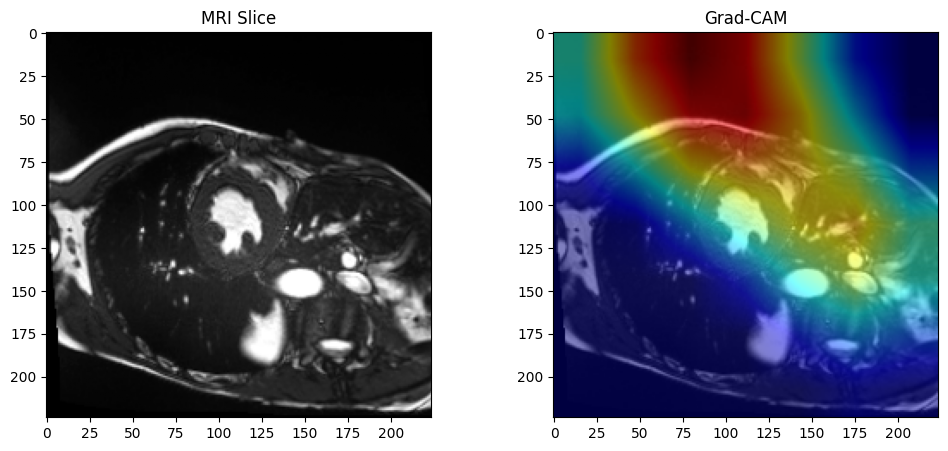

In [227]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(slice_img, cmap="gray")
plt.title("MRI Slice")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")

plt.show()

In [218]:
print(slice_img.shape)
print(slice_img_rgb.shape)
print(grayscale_cam.shape)


(224, 224)
(224, 224, 3)
(224, 224)


In [219]:
print("True label:", label.item())
print("Predicted:", pred_class)

True label: 1
Predicted: 4


In [220]:
class_names = ["NOR","DCM","HCM","MINF","RV"]

print("True:", class_names[label.item()])
print("Pred:", class_names[pred_class])

True: DCM
Pred: RV
